# Лаба 8

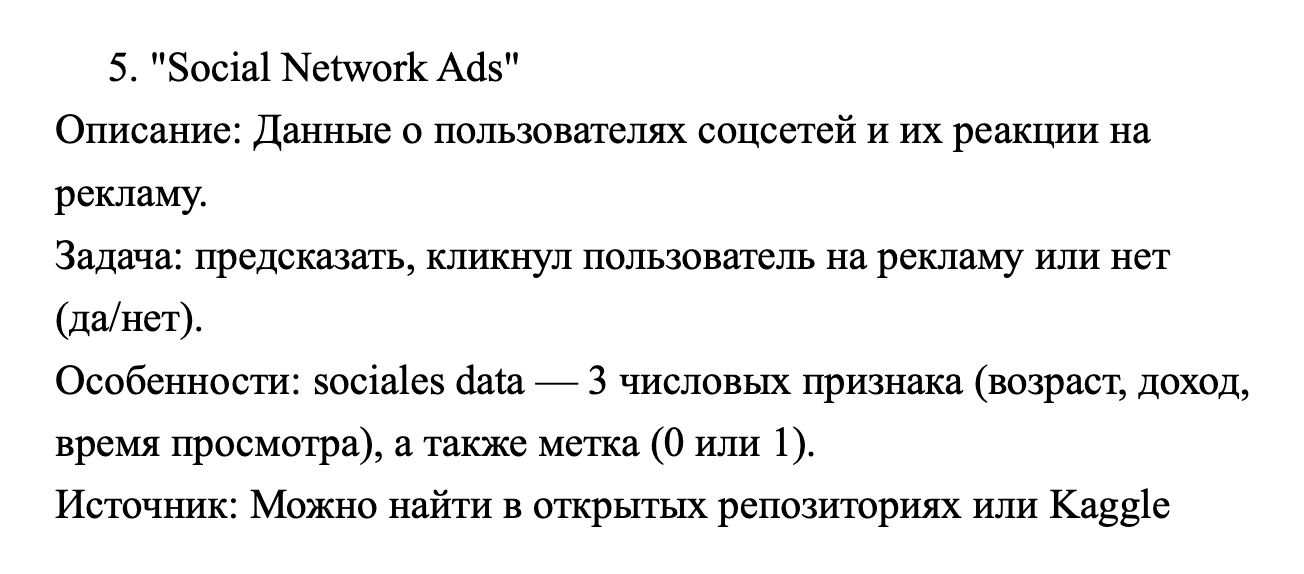

[скачал с Kaggle](https://www.kaggle.com/datasets/mdwasimakhtar03/social-network-adscsv?resource=download)

# Задания

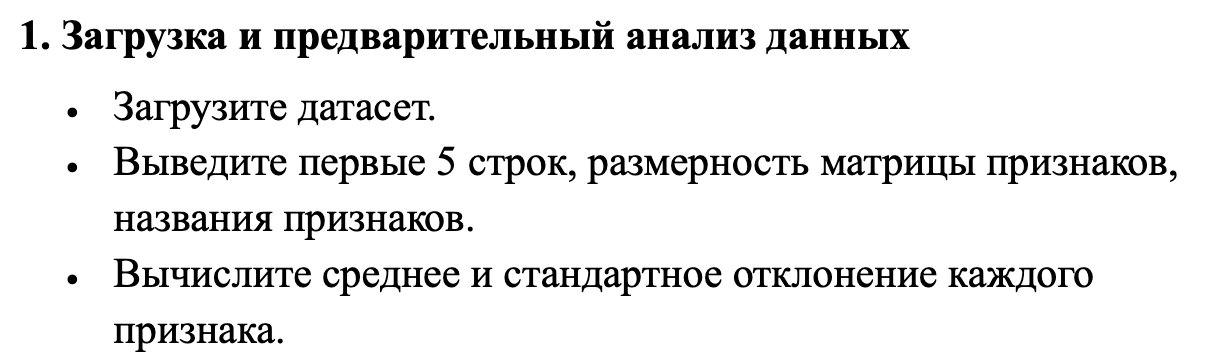

In [19]:
import pandas as pd

df = pd.read_csv('data/Social_Network_Ads.csv')

X = df.drop('Purchased', axis=1)
y = df['Purchased']

print("--- Первые 5 ---")
print(df.head())

print("\n--- Размерность ---")
print(f"Строк: {X.shape[0]}, Столбцов (признаков): {X.shape[1]}")

print("\n--- Признаки ---")
print(X.columns.tolist())

print("\n--- Среднее признаков ---")
print(X.mean())

print("\n--- Стандартное отклонение признаков ---")
print(X.std())

--- Первые 5 ---
   Age  EstimatedSalary  Purchased
0   19            19000          0
1   35            20000          0
2   26            43000          0
3   27            57000          0
4   19            76000          0

--- Размерность ---
Строк: 400, Столбцов (признаков): 2

--- Признаки ---
['Age', 'EstimatedSalary']

--- Среднее признаков ---
Age                   37.655
EstimatedSalary    69742.500
dtype: float64

--- Стандартное отклонение признаков ---
Age                   10.482877
EstimatedSalary    34096.960282
dtype: float64


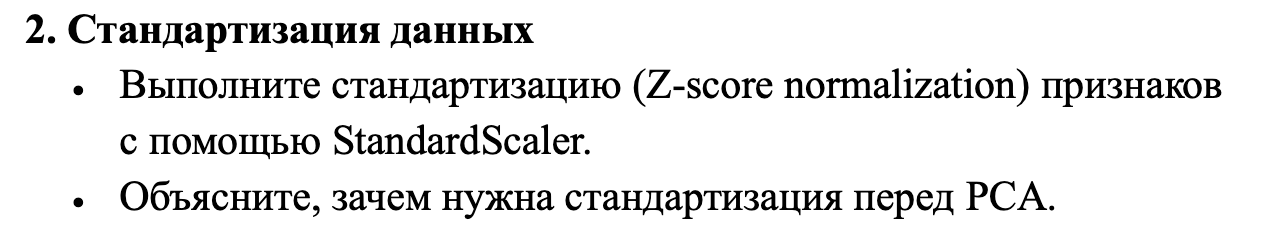

In [20]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)

print("--- Первые 5, стандартизированные ---")
print(X_scaled.head())

--- Первые 5, стандартизированные ---
        Age  EstimatedSalary
0 -1.781797        -1.490046
1 -0.253587        -1.460681
2 -1.113206        -0.785290
3 -1.017692        -0.374182
4 -1.781797         0.183751


## Зачем?

Масштабы признаков могут быть разные, из-за этого один может повлиять больше другого

поэтому их важно привести к одному масштабу

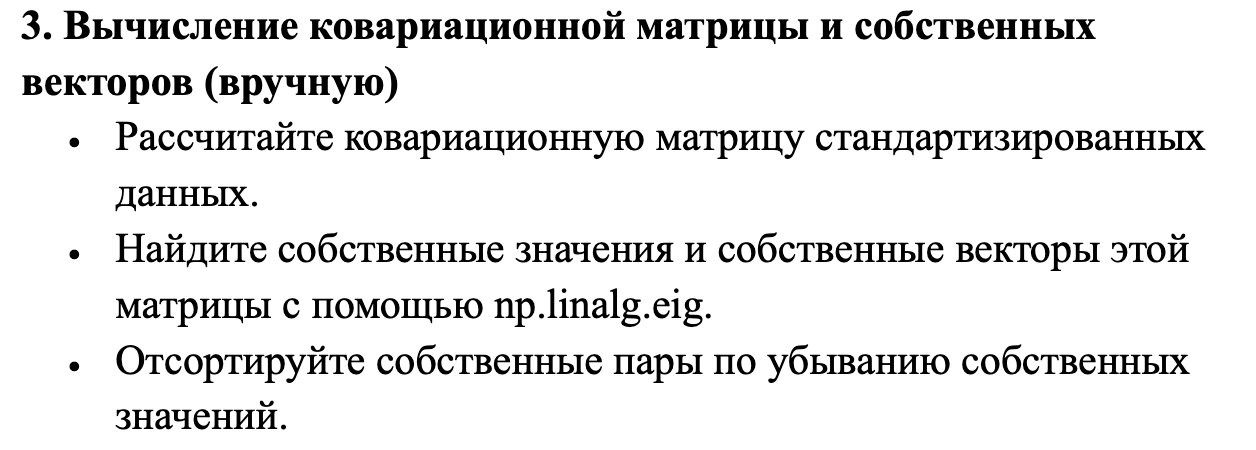

In [21]:
import numpy as np

# ковариционная матрица
cov_matrix = np.cov(X_scaled_array.T) # функция ожидает признаки в строках

print("--- Ковариационная м ---")
print(cov_matrix)

# собственные значния и векторы
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("\n--- СЗн ---")
print(eigenvalues)
print("\n--- СВ-ры ---")
print(eigenvectors)

# пары (СЗн, СВ-р-столбец)
eigen_pairs = [
    (np.abs(eigenvalues[i]), eigenvectors[:, i]) 
    for i in range(len(eigenvalues))
]
# по убыванию СЗн
eigen_pairs.sort(key=lambda x: x[0], reverse=True)

print("\n--- отсортировали СЗн ---")
for i in range(len(eigen_pairs)):
    print(f"главная компонента {i+1}: {eigen_pairs[i][0]:.4f}")

print("\n--- отсортировали СВ-ры ---")
for i in range(len(eigen_pairs)):
    print(f"вектор {i+1}: {eigen_pairs[i][1]}")

--- Ковариационная м ---
[[1.00250627 0.15562709]
 [0.15562709 1.00250627]]

--- СЗн ---
[1.15813335 0.84687918]

--- СВ-ры ---
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

--- отсортировали СЗн ---
главная компонента 1: 1.1581
главная компонента 2: 0.8469

--- отсортировали СВ-ры ---
вектор 1: [0.70710678 0.70710678]
вектор 2: [-0.70710678  0.70710678]


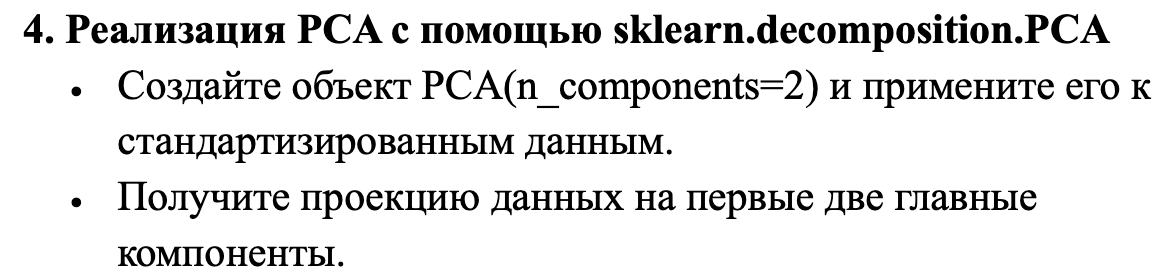

In [22]:
from sklearn.decomposition import PCA
import pandas as pd

# создаем
pca = PCA(n_components=2)

# применияем к стандартизированным
X_pca_array = pca.fit_transform(X_scaled_array)

# преобразуем DataFrame
df_pca = pd.DataFrame(data=X_pca_array, columns=['ГК1', 'ГК2'])

print("--- 5 строк ---")
print(df_pca.head())

print("\n--- размерность новых ---")
print(f"строк: {df_pca.shape[0]}, столбцов (компонент): {df_pca.shape[1]}")

--- 5 строк ---
        ГК1       ГК2
0 -2.313543  0.206299
1 -1.212171 -0.853544
2 -1.342439  0.231872
3 -0.984204  0.455031
4 -1.129990  1.389852

--- размерность новых ---
строк: 400, столбцов (компонент): 2


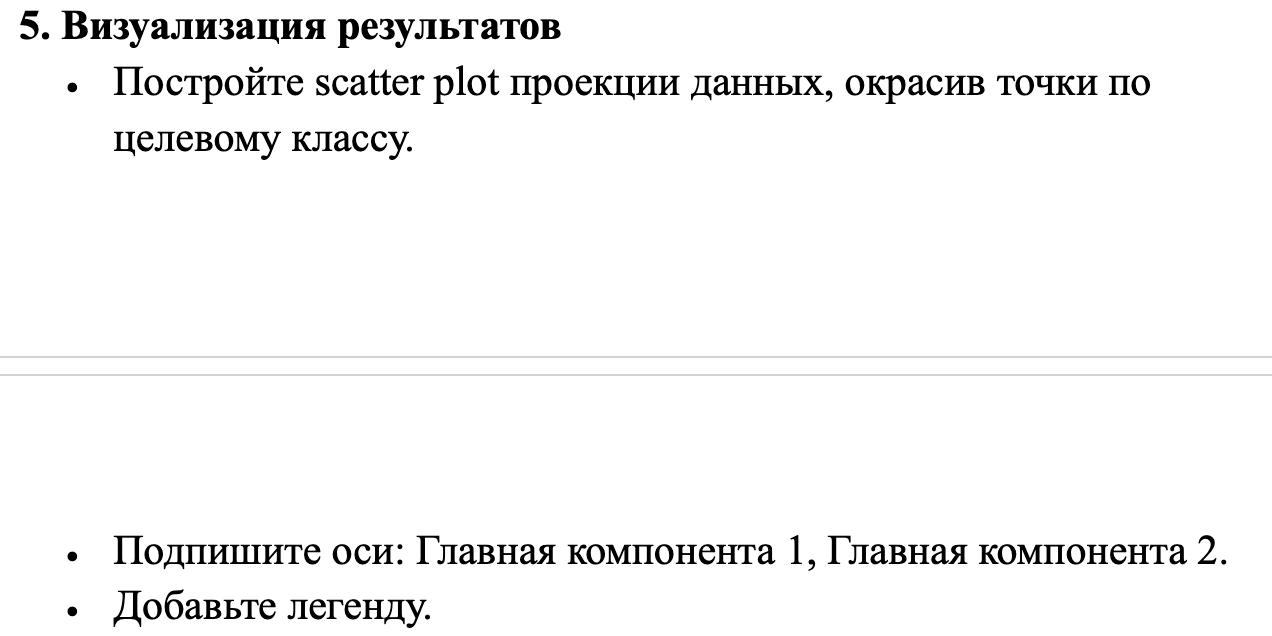

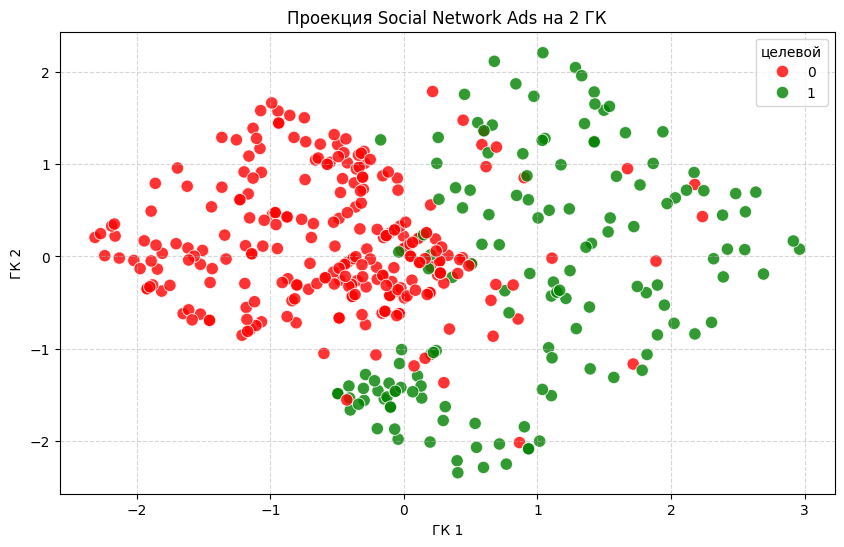

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot( # диаграмма рассеяния
    x='ГК1', 
    y='ГК2', 
    hue=y, # окрасит точки с такими y
    palette=['red', 'green'], # НЕ КУПИЛ и КУПИЛ
    data=df_pca,
    s=80, # размер точек
    alpha=0.8 # прозрачность
)

# Подписываем оси строго по заданию
plt.xlabel('ГК 1')
plt.ylabel('ГК 2')

# Добавляем заголовок и легенду
plt.title('Проекция Social Network Ads на 2 ГК')
plt.legend(title='целевой')

# Отображаем график
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

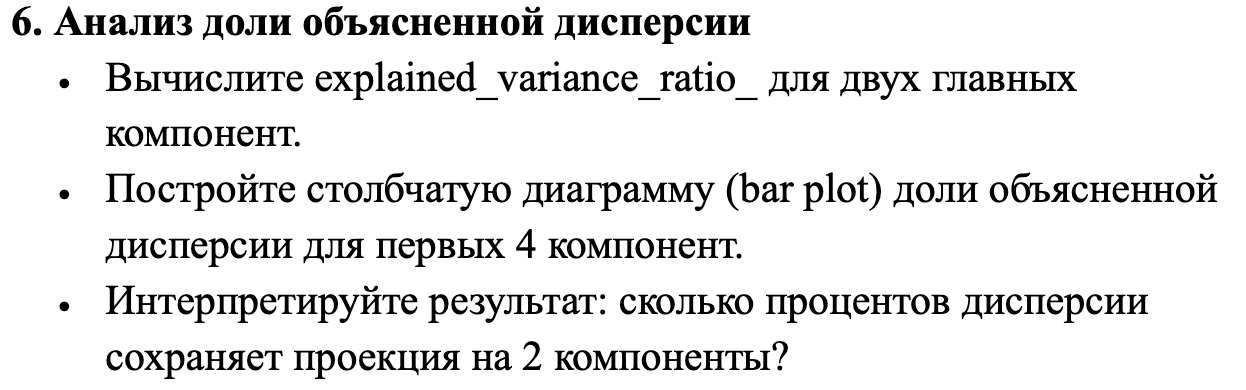

--- доля объясненной дисперсии по компонентам ---
ГК1: 0.5776 (57.76%)
ГК2: 0.4224 (42.24%)


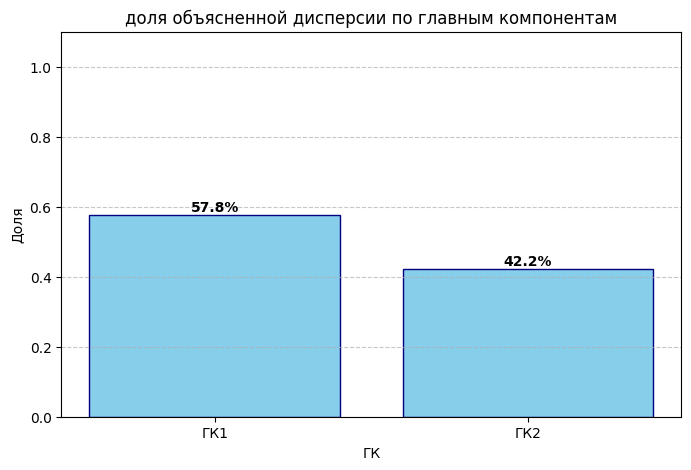


Суммарная объясненная дисперсия для 2-х компонент: 100.00%


In [24]:
import matplotlib.pyplot as plt
import numpy as np

# вычислил
variance_ratio = pca.explained_variance_ratio_

print("--- доля объясненной дисперсии по компонентам ---")
for i, ratio in enumerate(variance_ratio):
    print(f"ГК{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")

# столбчетая диаграмма
plt.figure(figsize=(8, 5))
components = [f'ГК{i+1}' for i in range(len(variance_ratio))]

plt.bar(components, variance_ratio, color='skyblue', edgecolor='navy')
for i, val in enumerate(variance_ratio):
    plt.text(i, val + 0.01, f'{val*100:.1f}%', ha='center', fontweight='bold')

plt.title('доля объясненной дисперсии по главным компонентам')
plt.xlabel('ГК')
plt.ylabel('Доля')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Вычисление суммарной дисперсии
total_variance = np.sum(variance_ratio) * 100
print(f"\nСуммарная объясненная дисперсия для 2-х компонент: {total_variance:.2f}%")

Сколько процентов дисперсии сохраняет проектция на 2 компоненты: мы сохранили и использовали 2 компоненты, это 100%. Это означает, что проекция на 2 компоненты сохраняет всю данную информацию

если бы "у нас 30 всего признаков, а сохранили 2", то -- суммараная дисперсия была бы меньше 100%, и мы бы тогда потеряли Сколько-то% информации

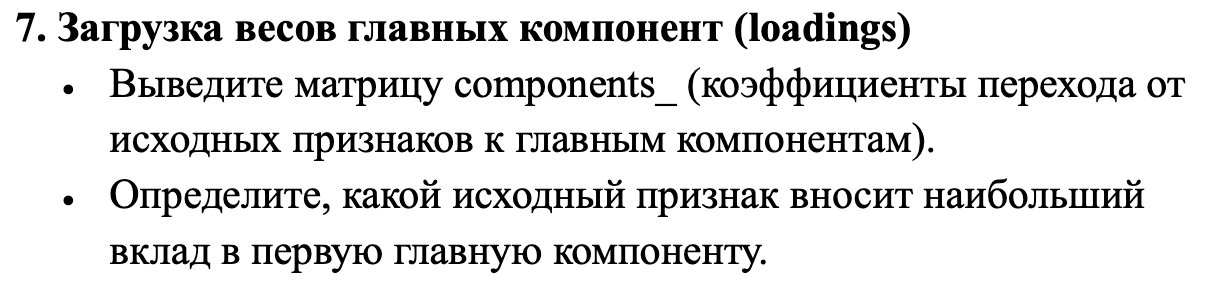

In [25]:
import pandas as pd
import numpy as np

# вывел
loadings = pd.DataFrame(
    data=pca.components_.T, 
    columns=['ГК1', 'ГК2'], 
    index=X.columns
)
print("--- components_ ---")
print(loadings)

# кто вносит наибольший вклад
# посмотрим для ГК1
pc1_contributions = loadings['ГК1'].abs() # смотрим на модуль значения
max_feature = pc1_contributions.idxmax()
max_value = pc1_contributions.max()

print(f"\nнаибольший вклад в ГК1 вносит признак: {max_feature}")
print(f"его абсолютный вес в ГК1: {max_value:.4f}")

--- components_ ---
                      ГК1       ГК2
Age              0.707107 -0.707107
EstimatedSalary  0.707107  0.707107

наибольший вклад в ГК1 вносит признак: Age
его абсолютный вес в ГК1: 0.7071
